In [10]:
import sys
sys.path.append("/home/patriciobarber/AdaptiveLatents")

import matplotlib.pyplot as plt
from adaptive_latents.input_sources.lds_simulation import LDS
import numpy as np
from workspace.neurips_2025.learn_s_hat_toy import n_rotations, stims_per_rotation, stim_magnitude, noise_variance

from workspace.neurips_2025.common import log_for_tex

## Run our toy model 

In [7]:
def show_toy_dataset():
    fig, ax = plt.subplots(subplot_kw=dict(projection="3d"))

    rng = np.random.default_rng(0)

    def u_function(lds, state, i, rng):
        u = np.zeros(lds.B.shape[0])
        if i == 20:
            u[2] = 5
        return u

    def true_S(lds, state, i, rng):
        u = np.zeros(3)
        if i in {16, 32, 80, 150}: # 52
            u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])
        return u

    show_toy_n_turns = log_for_tex(key='show_toy_n_turns', value=10, current_file=__file__, output_directory=args.output.parent)

    _, Y, stim = LDS.run_nest_dynamical_system(show_toy_n_turns, stims_per_rotation=stims_per_rotation, stim_magnitude=stim_magnitude, rng=rng, u_function=true_S, noise=noise_variance, radius=15)

    ax.plot(Y[:, 0], Y[:, 1], Y[:, 2])

    ax.axis('equal')
    ax.view_init(elev=24, azim=147, roll=0)
    # ax.axis((np.float64(-24.059680968092277), np.float64(27.5328712068437), np.float64(-26.059286658753816), np.float64(27.257531995356583), np.float64(-12.057545210133634), np.float64(11.79530183372015)))
    ax.axis((np.float64(-18), np.float64(15), np.float64(-15), np.float64(15), np.float64(-10), np.float64(10)))
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.xaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
    ax.yaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
    ax.zaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)


    return fig

### My refactorization to work with it modularly

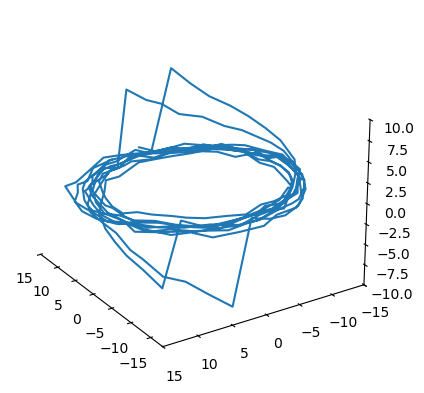

In [8]:
def generate_toy_dataset(
    n_turns=10,
    stims_per_rotation=10,
    stim_magnitude=1.0,
    noise_variance=0.1,
    radius=15,
    rng_seed=0
):
    rng = np.random.default_rng(rng_seed)

    def true_S(lds, state, i, rng):
        u = np.zeros(3)
        if i in {16, 32, 80, 150}:
            u[2] = stim_magnitude * state[0] / np.linalg.norm(state[:2])
        return u

    _, Y, stim = LDS.run_nest_dynamical_system(
        n_turns,
        stims_per_rotation=stims_per_rotation,
        stim_magnitude=stim_magnitude,
        rng=rng,
        u_function=true_S,
        noise=noise_variance,
        radius=radius
    )
    return Y, stim

def plot_toy_dataset(Y):
    fig, ax = plt.subplots(subplot_kw=dict(projection="3d"))
    ax.plot(Y[:, 0], Y[:, 1], Y[:, 2])
    ax.axis('equal')
    ax.view_init(elev=24, azim=147, roll=0)
    ax.axis((np.float64(-18), np.float64(15), np.float64(-15), np.float64(15), np.float64(-10), np.float64(10)))
    ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax.xaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
    ax.yaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
    ax.zaxis._axinfo["grid"]['color'] = (1, 1, 1, 0)
    return fig

# Example usage:
Y, stim = generate_toy_dataset(
    n_turns=10,
    stims_per_rotation=stims_per_rotation,
    stim_magnitude=stim_magnitude,
    noise_variance=noise_variance,
    radius=15,
    rng_seed=0
)
fig = plot_toy_dataset(Y)